In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt

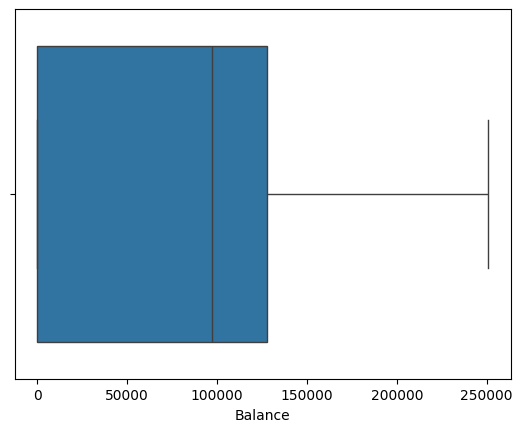

In [9]:
sns.boxplot(x=df['Balance'])
plt.show()

In [10]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [12]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis = 1 )

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
num_col = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
cat_col = ['Geography','Gender']

In [15]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [16]:
from sklearn.pipeline import make_pipeline

from sklearn.compose import ColumnTransformer

In [17]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_col),
    ('cat', OneHotEncoder(), cat_col)
])

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df[num_col + cat_col]

In [20]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography,Gender
0,619,42,2,0.00,1,1,1,101348.88,France,Female
1,608,41,1,83807.86,1,0,1,112542.58,Spain,Female
2,502,42,8,159660.80,3,1,0,113931.57,France,Female
3,699,39,1,0.00,2,0,0,93826.63,France,Female
4,850,43,2,125510.82,1,1,1,79084.10,Spain,Female
...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,France,Male
9996,516,35,10,57369.61,1,1,1,101699.77,France,Male
9997,709,36,7,0.00,1,0,1,42085.58,France,Female
9998,772,42,3,75075.31,2,1,0,92888.52,Germany,Male


In [21]:
y = df['Exited']

In [22]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [23]:
X_preprocessed = preprocessor.fit_transform(X)

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X_preprocessed, y, random_state = 42, stratify = y)

In [25]:
X_train

array([[ 0.87400456,  1.34240692,  1.03290776, ...,  0.        ,
         1.        ,  0.        ],
       [-1.37124577, -0.08789694, -0.69598177, ...,  0.        ,
         0.        ,  1.        ],
       [-0.81251988,  1.43776051,  1.37868567, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.17042381, -0.18325053,  1.37868567, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.37735933, -0.37395771,  1.03290776, ...,  1.        ,
         0.        ,  1.        ],
       [ 1.56723853,  1.15169974,  0.68712986, ...,  1.        ,
         0.        ,  1.        ]], shape=(7500, 13))

In [26]:
X_test

array([[-0.16067301, -0.4693113 , -0.00442596, ...,  1.        ,
         1.        ,  0.        ],
       [ 1.10163363, -0.85072567, -0.69598177, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.10834316, -0.37395771, -0.00442596, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.97806829,  1.15169974,  1.03290776, ...,  0.        ,
         1.        ,  0.        ],
       [-0.08824558,  1.5331141 ,  0.68712986, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.50152063, -0.27860412, -1.04175968, ...,  0.        ,
         0.        ,  1.        ]], shape=(2500, 13))

In [27]:
y_train

5866    1
1938    0
4194    0
6332    0
1       0
       ..
3254    1
4644    0
8942    0
2935    0
6206    0
Name: Exited, Length: 7500, dtype: int64

In [28]:
y_test

2605    0
9717    0
68      0
9397    0
4004    0
       ..
246     0
2538    0
5018    1
4536    0
7423    0
Name: Exited, Length: 2500, dtype: int64

In [ ]:
import tensorflow

from tensorflow import keras

from tensorflow.keras import Sequential

from tensorflow.keras.layers import Dense,Dropout


In [ ]:
model = Sequential([
    Dense(64,activation='relu',input_shape=(13,)),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='relu')
    
])

In [ ]:
model.summary()

In [ ]:
model.compile(optimizer='Adam',loss='binary_crossentropy')

In [ ]:
model.fit(X_train,y_train,epochs=100)

Fitting progress:-
Epoch 1/100
235/235 [==============================] - 1s 3ms/step - loss: 2.0761
Epoch 2/100
235/235 [==============================] - 1s 2ms/step - loss: 0.7605
Epoch 3/100
235/235 [==============================] - 1s 3ms/step - loss: 0.6556
Epoch 4/100
235/235 [==============================] - 1s 3ms/step - loss: 0.5971
Epoch 5/100
235/235 [==============================] - 1s 3ms/step - loss: 0.5463
Epoch 6/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4959
Epoch 7/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4920
Epoch 8/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4870
Epoch 9/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4658
Epoch 10/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4335
Epoch 11/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4423
Epoch 12/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4460
Epoch 13/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4447
Epoch 14/100
235/235 [==============================] - 1s 2ms/step - loss: 0.4236
Epoch 15/100
235/235 [==============================] - 1s 2ms/step - loss: 0.4149
Epoch 16/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4002
Epoch 17/100
235/235 [==============================] - 1s 2ms/step - loss: 0.4130
Epoch 18/100
235/235 [==============================] - 1s 2ms/step - loss: 0.4116
Epoch 19/100
235/235 [==============================] - 1s 2ms/step - loss: 0.4219
Epoch 20/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3950
Epoch 21/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3970
Epoch 22/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3904
Epoch 23/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3968
Epoch 24/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4052
Epoch 25/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3884
Epoch 26/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3826
Epoch 27/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3885
Epoch 28/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3827
Epoch 29/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3886
Epoch 30/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3860
Epoch 31/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3881
Epoch 32/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3954
Epoch 33/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3976
Epoch 34/100
235/235 [==============================] - 1s 3ms/step - loss: 0.4013
Epoch 35/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3915
Epoch 36/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3900
Epoch 37/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3944
Epoch 38/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3814
Epoch 39/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3984
Epoch 40/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3853
Epoch 41/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3865
Epoch 42/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3970
Epoch 43/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3744
Epoch 44/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3876
Epoch 45/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3812
Epoch 46/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3737
Epoch 47/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3889
Epoch 48/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3748
Epoch 49/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3774
Epoch 50/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3734
Epoch 51/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3825
Epoch 52/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3694
Epoch 53/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3744
Epoch 54/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3641
Epoch 55/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3661
Epoch 56/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3760
Epoch 57/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3823
Epoch 58/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3763
Epoch 59/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3868
Epoch 60/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3652
Epoch 61/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3644
Epoch 62/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3751
Epoch 63/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3821
Epoch 64/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3705
Epoch 65/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3767
Epoch 66/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3677
Epoch 67/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3864
Epoch 68/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3643
Epoch 69/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3582
Epoch 70/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3806
Epoch 71/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3708
Epoch 72/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3591
Epoch 73/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3612
Epoch 74/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3778
Epoch 75/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3683
Epoch 76/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3640
Epoch 77/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3515
Epoch 78/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3681
Epoch 79/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3648
Epoch 80/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3678
Epoch 81/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3609
Epoch 82/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3587
Epoch 83/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3648
Epoch 84/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3493
Epoch 85/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3605
Epoch 86/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3605
Epoch 87/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3688
Epoch 88/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3643
Epoch 89/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3613
Epoch 90/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3607
Epoch 91/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3624
Epoch 92/100
235/235 [==============================] - 1s 2ms/step - loss: 0.3674
Epoch 93/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3668
Epoch 94/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3649
Epoch 95/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3619
Epoch 96/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3808
Epoch 97/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3508
Epoch 98/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3711
Epoch 99/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3629
Epoch 100/100
235/235 [==============================] - 1s 3ms/step - loss: 0.3630
<keras.callbacks.History at 0x7bf25534e590>

In [ ]:
model.layers[0].get_weights()

In [ ]:
model.predict(X_test)

In [ ]:
 y_pred = []
for i in model.predict(X_test):
   
    if i <= 0.5:
        y_pred.append(0)
    else:
        y_pred.append(1)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

In [2]:
accuracy
accuracy i got is 0.8568

NameError: name 'accuracy' is not defined